# the results are a bit mid, what if we center at a gene and perturb the enhancer?

In [ ]:
#this makes it easier to see potentially and consistent with TSS based model

#first let's load the things in and test to see if we can recreate results



In [1]:
#so here's what we would load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

# gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
# gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)
    
name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
#ensure all names are in the tss_dict
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
        
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
gs_df


,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [2]:
#and the evals dataset
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
import torch
from tqdm import tqdm
from src.dataloaders.datasets.general_dataset import GeneralDataset
from src.models.sequence.dna_embedding import DNAEmbeddingModelCaduceus
from src.tasks.decoders import EnformerDecoder
from src.tasks.encoders import JointCNN
from caduceus.configuration_caduceus import CaduceusConfig
import yaml
from omegaconf import OmegaConf
import os
import itertools
import inspect
try:
    OmegaConf.register_new_resolver('eval', eval)
    OmegaConf.register_new_resolver('div_up', lambda x, y: (x + y - 1) // y)
except ValueError as e:
    if "Resolver already registered" in str(e):
            print("Resolver already exists, skipping registration.")

# from evals_utils_joint import Evals
class Evals():
    def __init__(self,
                 ckpt_path,
                 dataset=None,
                 split = 'test',
                 device = None,
                 load_data=False,
                 **dataset_overrides #Don't pass None into overrides unless you intentionally want it to be None! Pass in items only that you need
                 ) -> None:
        
        #now load the cfg from the checkpoint path
        model_cfg_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), '.hydra', 'config.yaml')
        cfg = yaml.load(open(model_cfg_path, 'r'), Loader=yaml.FullLoader)
        cfg = OmegaConf.create(cfg)
        self.cfg = OmegaConf.to_container(cfg, resolve=True)
        
        state_dict = torch.load(ckpt_path, map_location='cpu')
        if device is not None:
            #if we are given a device, we will use that device
            self.device = torch.device(device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.split = split

        #now set up dataset
        if dataset is None:
            dataset_args = self.cfg['dataset']
            assert dataset_args['mlm'] == 0 and dataset_args['acc_mlm'] == 0, "MLM and acc_mlm should be 0 for the training"
            sig = inspect.signature(GeneralDataset.__init__)
            sig = {k: v for k, v in sig.parameters.items() if k != 'self'}
            to_remove = []
            for k, v in dataset_args.items():
                if k not in sig:
                    # del dataset_args[k]
                    to_remove.append(k)
            for k in to_remove:
                del dataset_args[k]
            dataset_args['split'] = split
            dataset_args['evaluating'] = True #this tells it to not do things like random shifting and rc aug, still does random masking tho, can get og sequence easily
            dataset_args['load_in'] = load_data
            dataset_args['additional_data'] = None #override so we can load the dataset!
            
            for k, v in dataset_overrides.items():
                if k in sig:
                    dataset_args[k] = v
                    print(f"Overriding {k} with {v}")
                else:
                    print(f"Warning: {k} not in dataset args, skipping")
            
            # dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset_args = dataset_args
            # self.dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset = GeneralDataset(**dataset_args)
            
            # self.kmer_len = dataset_args['kmer_len']
            # self.dataset = enformer_dataset.EnformerDataset(split, dataset_args['max_length'], rc_aug = dataset_args['rc_aug'],
            #                                                 return_CAGE=dataset_args['return_CAGE'], cell_type=dataset_args.get('cell_type', None),
            #                                                 kmer_len=dataset_args['kmer_len']) #could use dataloader instead, but again kinda complex
        else:
            self.dataset = dataset
         
        torch.nn.modules.utils.consume_prefix_in_state_dict_if_present(
            state_dict["state_dict"], "model."
        )
        model_state_dict = state_dict["state_dict"]
        # need to remove torchmetrics. to remove keys, need to convert to list first
        for key in list(model_state_dict.keys()):
            if "torchmetrics" in key:
                model_state_dict.pop(key)
        # the state_dict keys slightly mismatch from Lightning..., so we fix it here
        decoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "decoder" in key:
                decoder_state_dict[key[10:]] = model_state_dict.pop(key)
        encoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "encoder" in key:
                encoder_state_dict[key[10:]] = model_state_dict.pop(key)
        
        cfg['model']['config'].pop('_target_')
        # cfg['model']['config']['complement_map'] = self.dataset.tokenizer.complement_map
        caduceus_cfg = CaduceusConfig(**cfg['model']['config'])
        
        self.backbone = DNAEmbeddingModelCaduceus(config=caduceus_cfg)
        self.backbone.load_state_dict(model_state_dict, strict=True)
        
        #remove self.cfg['decoder']['_name_']
        del self.cfg['decoder']['_name_']
        self.cfg['decoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.decoder = EnformerDecoder(**self.cfg['decoder']) #could do with instantiating, but that is rather complex
        self.decoder.load_state_dict(decoder_state_dict, strict=True)
        
        del self.cfg['encoder']['_name_']
        self.cfg['encoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.encoder = JointCNN(**self.cfg['encoder'])
        self.encoder.load_state_dict(encoder_state_dict, strict=True)
        
        self.encoder.to(self.device).eval()
        self.backbone.to(self.device).eval()
        self.decoder.to(self.device).eval()
        
    def __call__(self, idx=None, data=None):
        #now evaluate the model on one example
        if data is None:
            (seq,acc),_ = self.dataset[idx]
            
            x = seq.unsqueeze(0)
            y = acc.unsqueeze(0)
        else:
            (x,y),_ = data

            if x.dim() == 2:
                x = x.unsqueeze(0) #add batch dim
                y = y.unsqueeze(0) #add batch dim
        
        x,y = x.to(self.device), y.to(self.device)
        
        with torch.no_grad():
            x1,_ = self.encoder(x,y)
            x1,_ = self.backbone(x1)
            x1 = self.decoder(x1)
        
        return x1

#this is the model that was trained on unstranded cage at 128 bp resolution. Let's see if it even predicts these values!
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2025-08-15/12-23-01-318424/checkpoints/last.ckpt'
evals = Evals(ckpt_path,load_data=True, device=0)

#first we have to see the prediction of this region, then extend the dataset

JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>


In [3]:
#let's see prediction then
idx = 0
row = gs_df.iloc[idx]

chrom = row['chrom']
start = row['chromStart']
end = row['chromEnd']
ensgid = row['ensg_id']
temp_tss = tss_dict[ensgid]['tss']
temp_tss, chrom, start, end

(3857233, 'chr1', 3774714, 3775214)

In [4]:
#now let's put it into the dataset and then see based on our indexing if we see the same 2 peaks
idx = evals.dataset.expand_seqs(chrom, temp_tss, temp_tss)
((s,a),(su,au)) = evals.dataset[idx]
s = s.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 6 x 524288
a = a.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 2 x 524288

In [5]:
#now let's plot the accessibility
#first manually find the region
a.shape


torch.Size([2, 2, 524288])

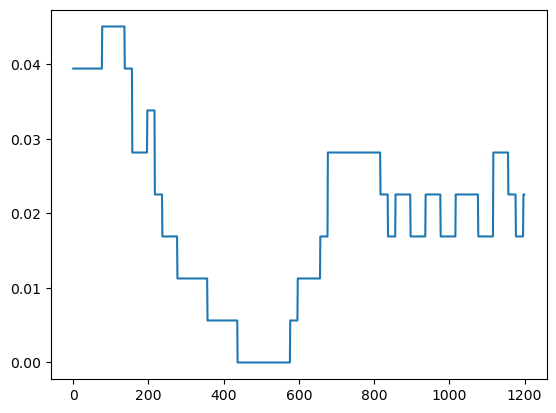

In [9]:
#so we center at TSS, find the distance
peak_len = (end - start) + 100
mid = (start + end) // 2
diff = mid - temp_tss
plt.plot(a[0,0,diff-peak_len:diff+peak_len])

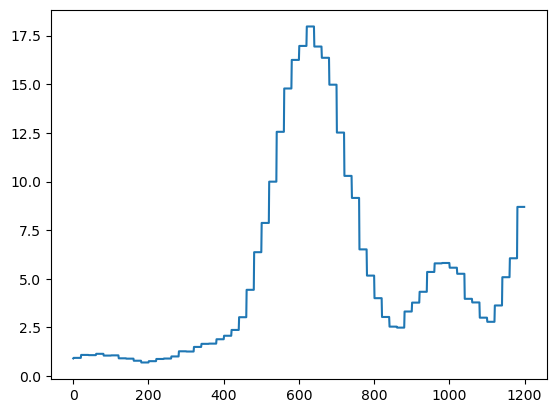

In [10]:
#doesn't account for the fact that we center at TSS, so add the middle
loc = diff + 524288//2
plt.plot(a[0,0,loc-peak_len:loc+peak_len])

In [11]:
#test it with this
gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)
gs_df_regulated

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
3347,FlowFISH_K562,chr17,32909510,32913691,TMEM98|chr17:31236528-31240709:*,-0.932000,chr17,32927910.0,32927911.0,TMEM98,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|TMEM98|chr17:31236528-31240709:*,3388,32909510,32913691,ENSG00000006042
10215,FlowFISH_K562,chrX,55028229,55028268,ALAS2|chrX:55054662-55054701:*,-0.930000,chrX,55031063.0,55031064.0,ALAS2,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|ALAS2|chrX:55054662-55054701:*,10346,55028229,55028268,ENSG00000158578
5207,FlowFISH_K562,chr19,48963708,48964208,FTL|chr19:49466965-49467465:*,-0.900693,chr19,48965301.0,48965302.0,FTL,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|FTL|chr19:49466965-49467465:*,5268,48963708,48964208,ENSG00000087086
2638,FlowFISH_K562,chr12,54304241,54304761,NFE2|chr12:54698025-54698545:*,-0.892641,chr12,54301120.0,54301121.0,NFE2,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|NFE2|chr12:54698025-54698545:*,2669,54304241,54304761,ENSG00000123405
7951,FlowFISH_K562,chr6,37183271,37183514,PIM1|chr6:37151047-37151290:*,-0.888781,chr6,37170203.0,37170204.0,PIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|PIM1|chr6:37151047-37151290:*,8069,37183271,37183514,ENSG00000137193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362,Gasperini2019,chr21,43397742,43398833,PKNOX1|chr21:44817622-44818713:.,-0.006984,chr21,42974510.0,42974511.0,PKNOX1,...,True,0.05,0.05,0.15,1.00,Gasperini2019|PKNOX1|chr21:44817622-44818713:.,6444,43397742,43398833,ENSG00000160199
2142,Gasperini2019,chr11,65362343,65362917,FIBP|chr11:65129814-65130388:.,-0.003123,chr11,65888538.0,65888539.0,FIBP,...,True,0.45,0.60,0.80,1.00,Gasperini2019|FIBP|chr11:65129814-65130388:.,2163,65362343,65362917,ENSG00000172500
842,Gasperini2019,chr10,12265775,12266275,SEC61A2|chr10:12307774-12308274:.,-0.001270,chr10,12129637.0,12129638.0,SEC61A2,...,True,0.00,0.00,0.00,0.10,Gasperini2019|SEC61A2|chr10:12307774-12308274:.,852,12265775,12266275,ENSG00000065665
8100,Gasperini2019,chr6,144215306,144215806,PLAGL1|chr6:144536443-144536943:.,-0.000975,chr6,144064598.0,144064599.0,PLAGL1,...,True,0.00,0.10,0.25,0.75,Gasperini2019|PLAGL1|chr6:144536443-144536943:.,8220,144215306,144215806,ENSG00000118495


In [12]:
row = gs_df_regulated.iloc[0]
chrom = row['chrom']
start = row['chromStart']
end = row['chromEnd']
ensgid = row['ensg_id']
temp_tss = tss_dict[ensgid]['tss']

idx = evals.dataset.expand_seqs(chrom, temp_tss, temp_tss)
((s,a),(su,au)) = evals.dataset[idx]
s = s.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 6 x 524288
a = a.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 2 x 524288

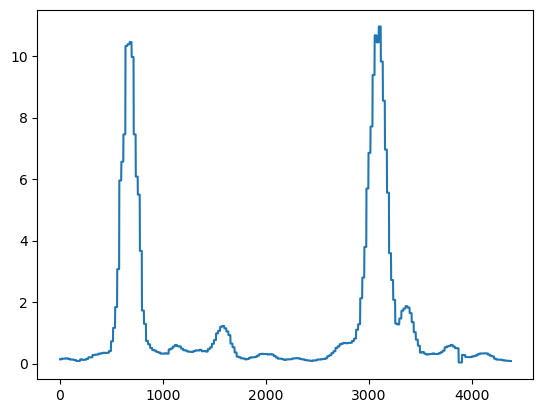

In [15]:
peak_len = (end - start)//2 + 100
mid = (start + end) // 2
diff = mid - temp_tss
loc = diff + 524288//2
plt.plot(a[0,0,loc-peak_len:loc+peak_len])

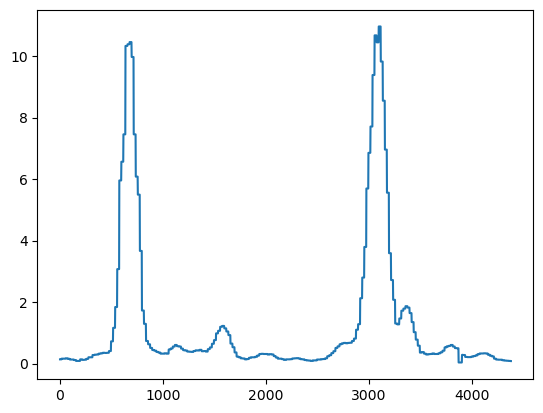

In [ ]:
#exactly the same I think were'g ood!!
#just to double check, let's plot it the same way they do
HALF = 524288//2
seq_start = temp_tss - HALF
startmask = (start - seq_start) - 100
endmask   = (end   - seq_start) + 100
plt.plot(a[0,0,startmask:endmask]) #yessir!

In [ ]:
#so we confirmed the logic! Now we know we're masking the peak correctly

# calculating AUPR again

In [17]:
#instead of using all TSS, let's only use the main one for this first score
#can use alternate ones after this
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_unstranded_enformer_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_unstranded_enformer_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

(10280, 2, 896) (10280,)


In [ ]:
in_context.sum() #only like half... shit but I guess it's ok?

3950

In [19]:
from tqdm import tqdm
score_vector = np.zeros(len(gs_df))
mask_len_maintss = 3
mask_len_alttss = 0
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    
    # 1. Main TSS is ALWAYS dead center now
    gene_location = 896 // 2 
    
    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(896, gene_location + mask_len_maintss + 1)
    
    mask = np.zeros(896)
    mask[startmask:endmask] = 1
    
    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
    
    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(896 // 2 + alt // 128)
            
            # Alt TSSs can still fall outside the 896-bin (~114kb) output window
            if alt_location < 0 or alt_location >= 896:
                continue
            
            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(896, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1
            
    # 3. Apply the mask to the vector
    tempout = outputs[i] # 2x896
    original_sum = (tempout[0] * mask).sum() 
    altered_sum = (tempout[1] * mask).sum()
    
    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:00<00:00, 15608.06it/s]


AUPR: 0.3509


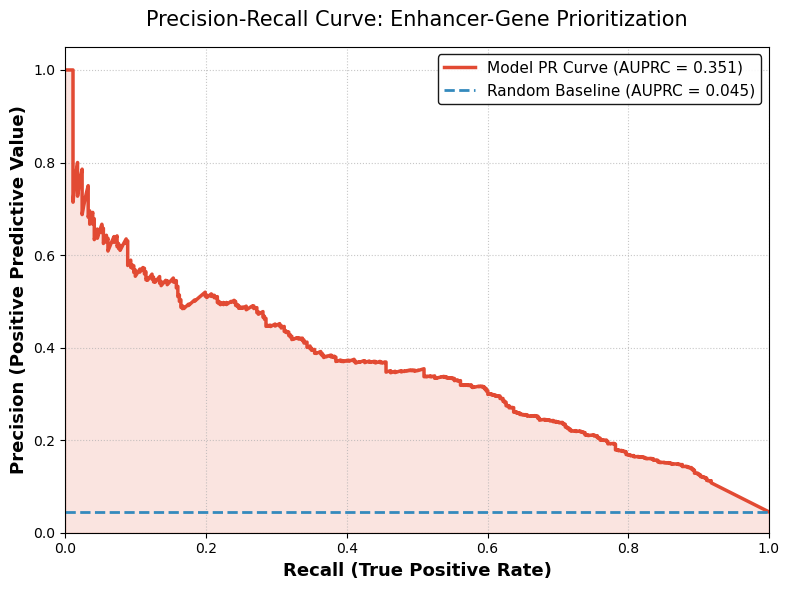

In [20]:
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

In [22]:
distance_vector = np.zeros(len(gs_df))
for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    distance_vector[i] = abs(temp_tss - ((start+end)//2))
gs_df['distance_to_tss'] = distance_vector

100%|██████████| 10280/10280 [00:00<00:00, 22162.59it/s]


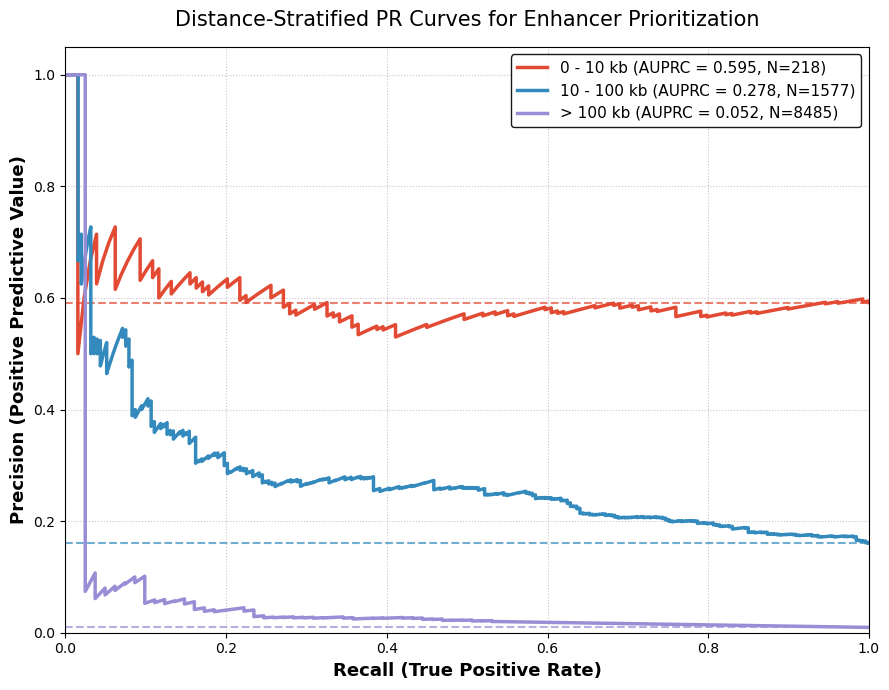

In [23]:
# 1. Prepare the data
y_true = gs_df['Regulated'].astype(int).values
y_score = np.abs(score_vector)
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", distances <= 10000),
    ("10 - 100 kb", (distances > 10000) & (distances <= 100000)),
    ("> 100 kb", distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

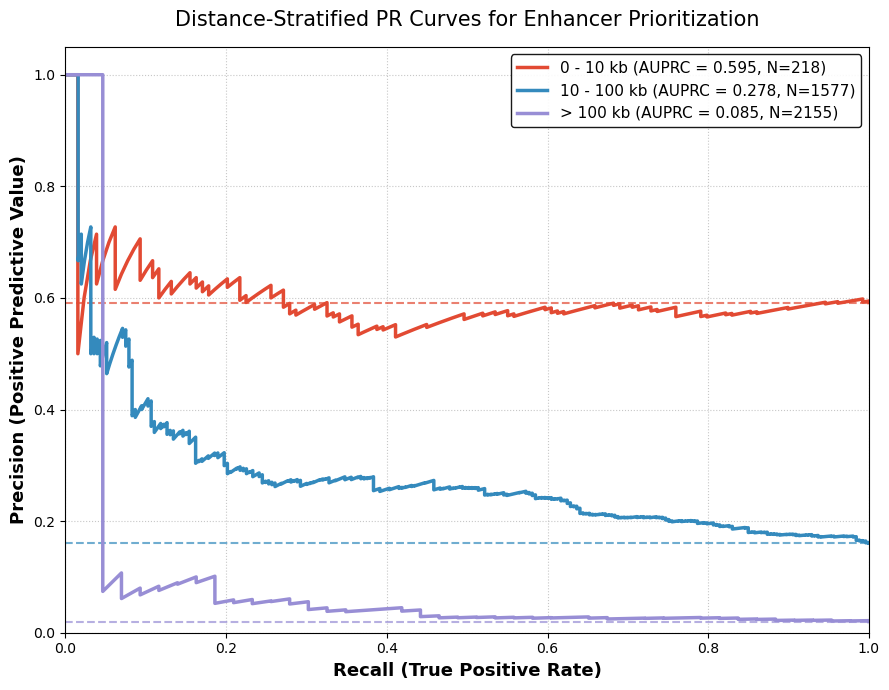

In [24]:
#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

In [25]:
#let's use alt TSS
from tqdm import tqdm
score_vector = np.zeros(len(gs_df))
mask_len_maintss = 3
mask_len_alttss = 1
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    
    # 1. Main TSS is ALWAYS dead center now
    gene_location = 896 // 2 
    
    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(896, gene_location + mask_len_maintss + 1)
    
    mask = np.zeros(896)
    mask[startmask:endmask] = 1
    
    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
    
    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(896 // 2 + alt // 128)
            
            # Alt TSSs can still fall outside the 896-bin (~114kb) output window
            if alt_location < 0 or alt_location >= 896:
                continue
            
            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(896, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1
            
    # 3. Apply the mask to the vector
    tempout = outputs[i] # 2x896
    original_sum = (tempout[0] * mask).sum() 
    altered_sum = (tempout[1] * mask).sum()
    
    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:00<00:00, 22008.52it/s]


AUPR: 0.3522


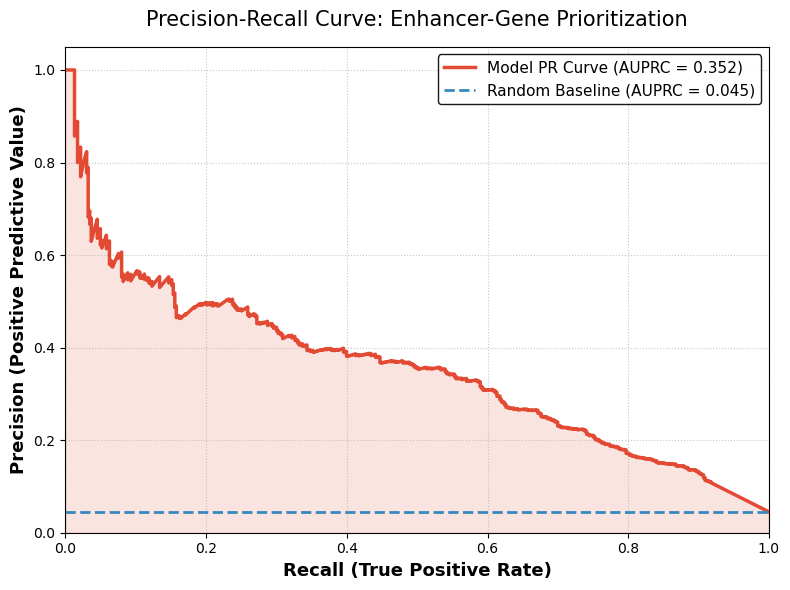

In [26]:
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

AUPR: 0.3769


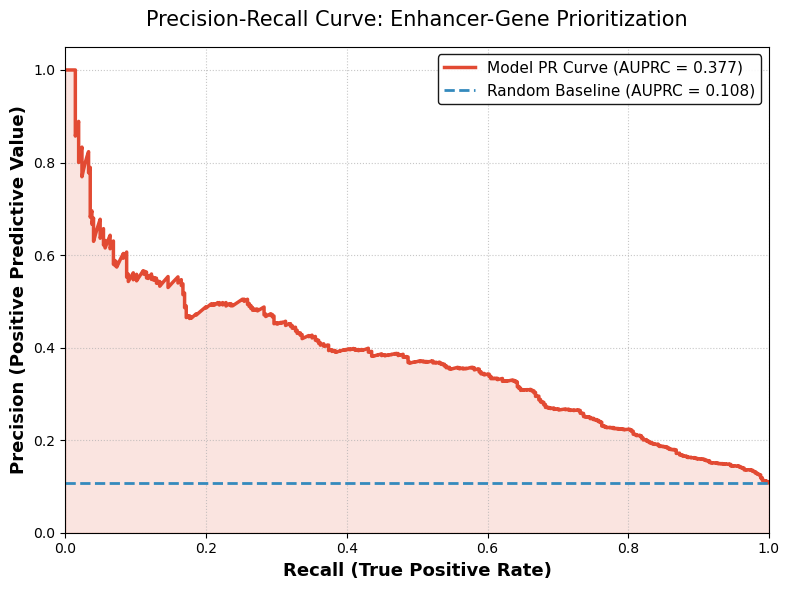

In [29]:
#and do it in context only
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

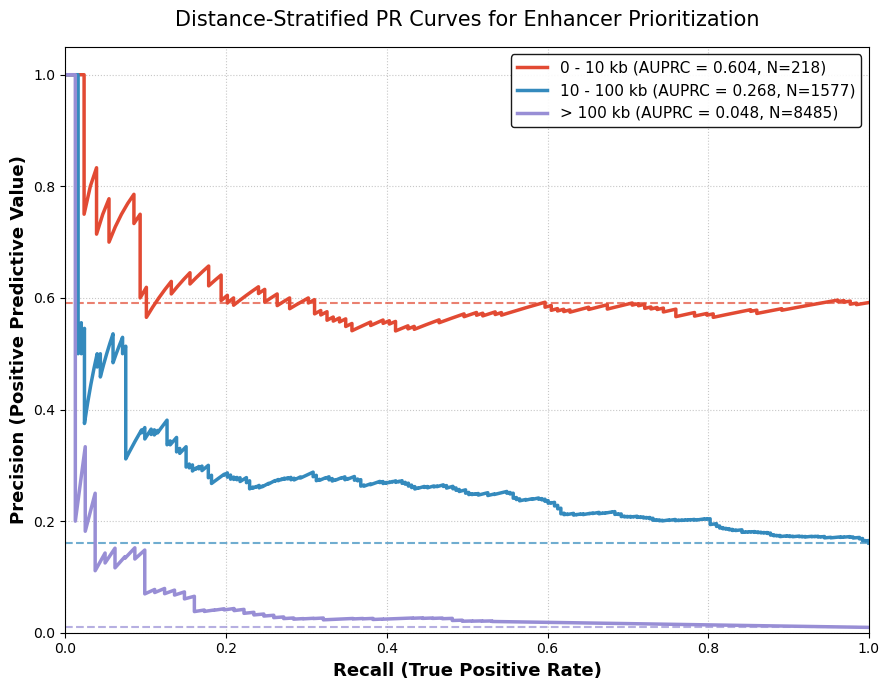

In [27]:
# 1. Prepare the data
y_true = gs_df['Regulated'].astype(int).values
y_score = np.abs(score_vector)
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", distances <= 10000),
    ("10 - 100 kb", (distances > 10000) & (distances <= 100000)),
    ("> 100 kb", distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

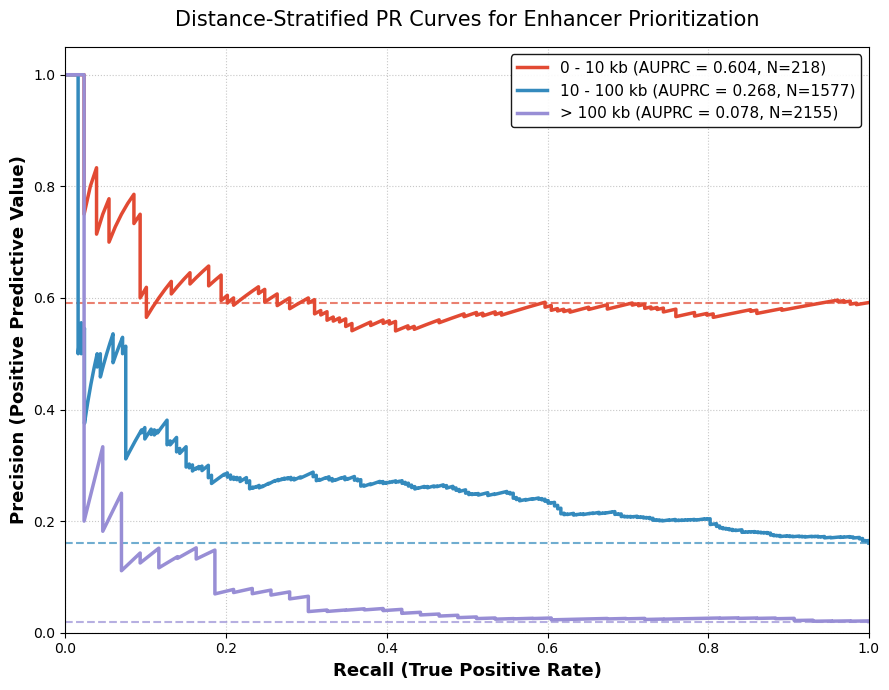

In [28]:
#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

# let's test borzoi type models, first the pure CAGE ones

In [32]:
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

(10280, 4, 6144) (10280,)


In [34]:
#seems fine, the key thing is we have to also consider strand!

from tqdm import tqdm
score_vector = np.zeros(len(gs_df))
mask_len_maintss = 3*4
mask_len_alttss = 0*4
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    strand = tss_dict[ensgid]['strand']
    
    # 1. Main TSS is ALWAYS dead center now
    gene_location = 6144 // 2 
    
    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(6144, gene_location + mask_len_maintss + 1)
    
    mask = np.zeros(6144)
    mask[startmask:endmask] = 1
    
    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
    
    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(6144 // 2 + alt // 32)
            
            # Alt TSSs can still fall outside the 6144-bin (~114kb) output window
            if alt_location < 0 or alt_location >= 6144:
                continue
            
            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(6144, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1
            
    # 3. Apply the mask to the vector
    tempout = outputs[i] # 4x6144
    if strand == '+':
        og_idx = 0
        alt_idx = 2
    else:
        og_idx = 1
        alt_idx = 3
    original_sum = (tempout[og_idx] * mask).sum() 
    altered_sum = (tempout[alt_idx] * mask).sum()
    
    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:00<00:00, 16643.52it/s]


AUPR: 0.4171


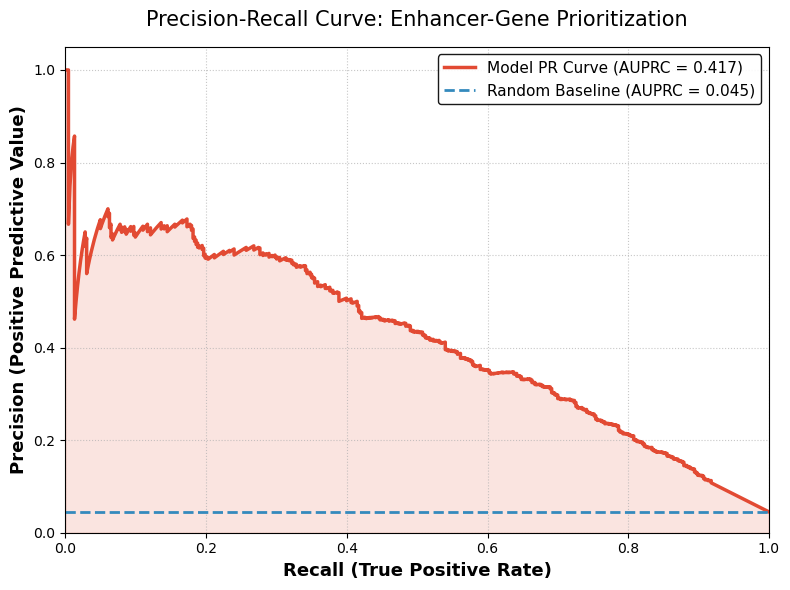

In [35]:
#
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

AUPR: 0.4476


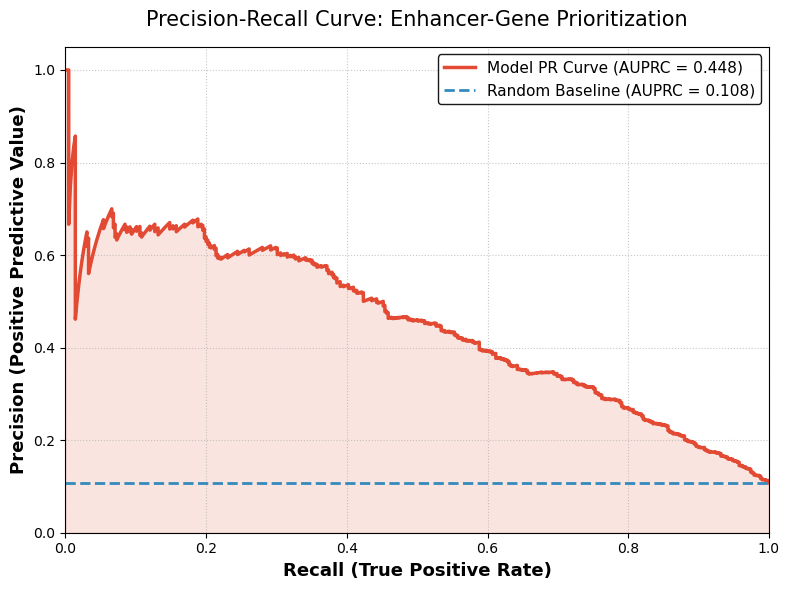

In [36]:
#and only in context now
#and do it in context only
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

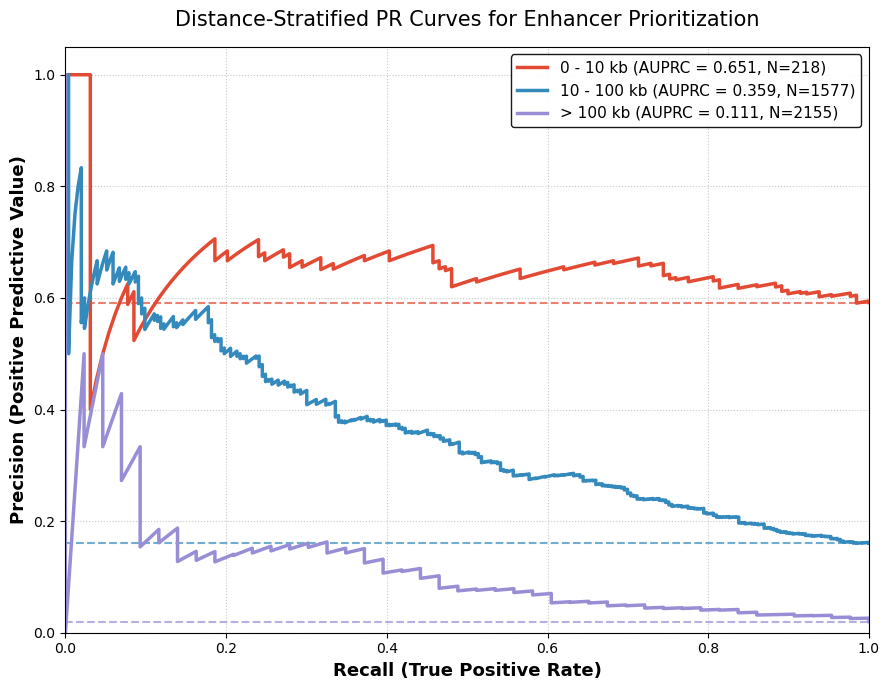

In [37]:
#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

# making code cleaner and easier to visualize

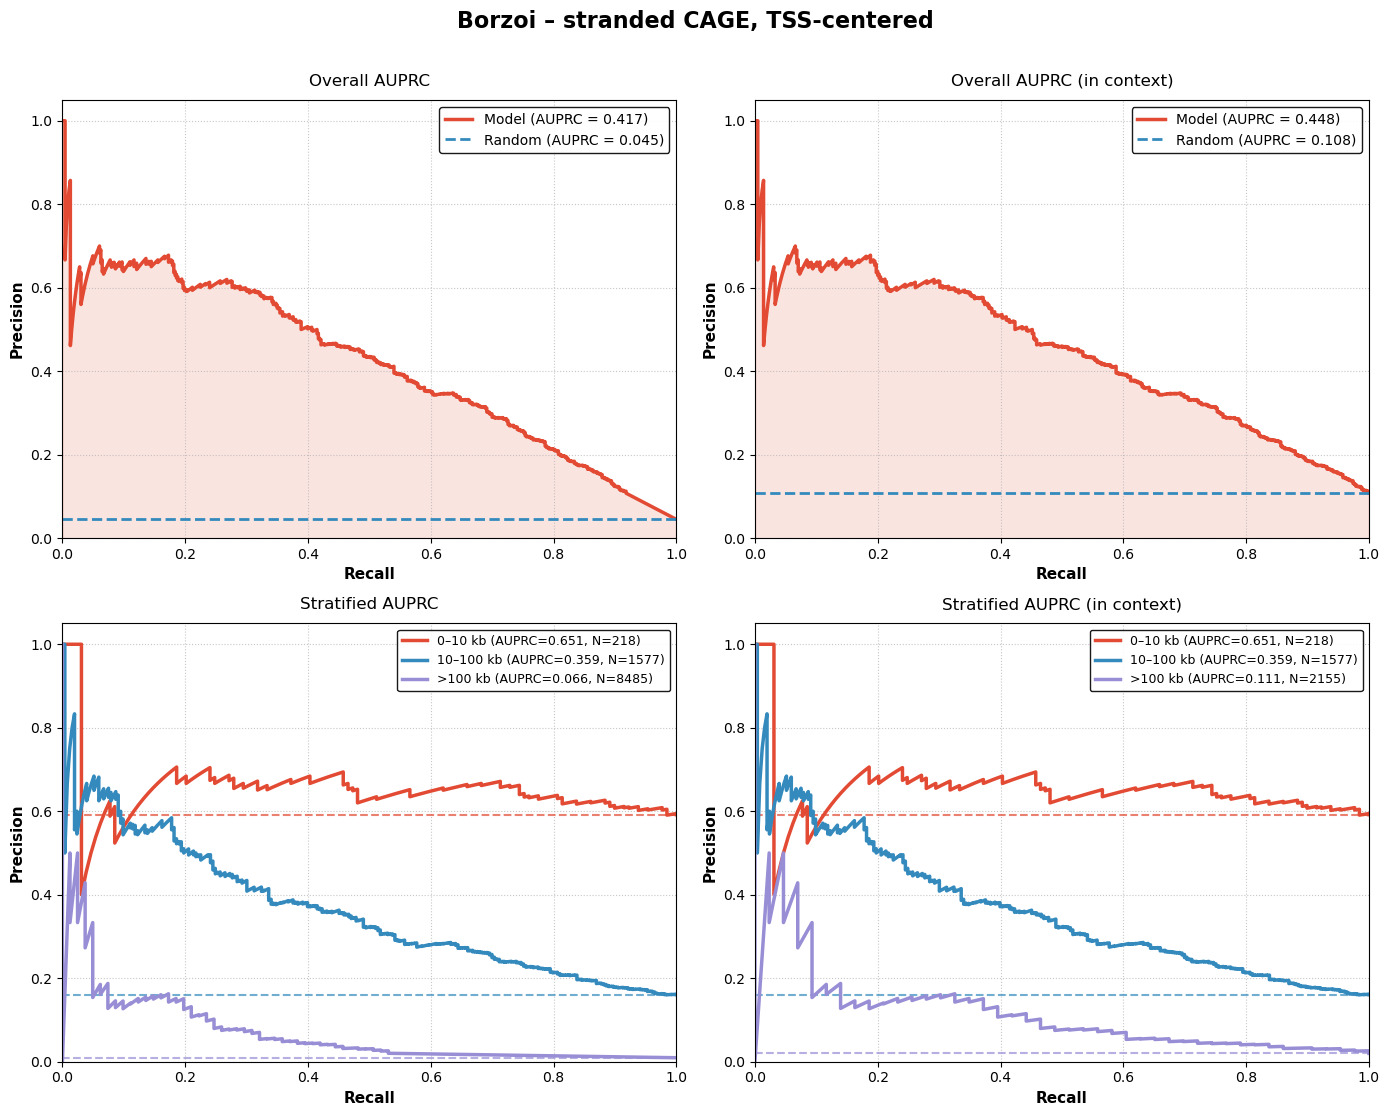

In [39]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title=None):
    """
    2x2 subplot summary of AUPRC performance.
    
    Parameters
    ----------
    score_vector  : np.ndarray (N,)  – pre-computed scores (e.g. log2 fold-change)
    in_context    : np.ndarray (N,)  – boolean mask of enhancers within the input crop
    gs_df         : pd.DataFrame     – must contain 'Regulated' column
    distance_vector : np.ndarray (N,) – enhancer-to-TSS distances (absolute values)
    title         : str, optional    – overall figure suptitle
    """
    y_score_all = np.abs(score_vector)
    y_true_all  = gs_df['Regulated'].astype(int).values
    dist_all    = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx  = y_true_all[in_context]
    dist_ctx    = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",    lambda d: d <= 10_000),
        ("10–100 kb",  lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",    lambda d: d > 100_000),
    ]
    bin_colors = ['#E24A33', '#348ABD', '#988ED5']

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    # ── helper: single overall PR curve ──────────────────────────────────────
    def _plot_overall(ax, y_true, y_score, subtitle):
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        aupr     = auc(rec, prec)
        baseline = y_true.mean()

        ax.plot(rec, prec, color='#E24A33', lw=2.5,
                label=f'Model (AUPRC = {aupr:.3f})')
        ax.fill_between(rec, prec, alpha=0.15, color='#E24A33')
        ax.axhline(baseline, color='#348ABD', lw=2, linestyle='--',
                   label=f'Random (AUPRC = {baseline:.3f})')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

    # ── helper: distance-stratified PR curves ────────────────────────────────
    def _plot_stratified(ax, y_true, y_score, distances, subtitle):
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances)
            if mask.sum() == 0:
                continue
            yt, ys = y_true[mask], y_score[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr     = auc(rec, prec)
            baseline = yt.mean()
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f'{label} (AUPRC={aupr:.3f}, N={mask.sum()})')
            ax.axhline(baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='black')

    # ── fill the 4 panels ────────────────────────────────────────────────────
    _plot_overall   (axes[0, 0], y_true_all, y_score_all, 'Overall AUPRC')
    _plot_overall   (axes[0, 1], y_true_ctx, y_score_ctx, 'Overall AUPRC (in context)')
    _plot_stratified(axes[1, 0], y_true_all, y_score_all, dist_all, 'Stratified AUPRC')
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx, 'Stratified AUPRC (in context)')

    plt.tight_layout()
    plt.show()


# ── example usage ─────────────────────────────────────────────────────────────
# plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector,
#                title='Enformer – unstranded CAGE, TSS-centered')

plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title='Borzoi – stranded CAGE, TSS-centered')

In [48]:

#now make this a function

def make_score_vector(mask_len_maintss, mask_len_alttss, pseudo_count):
    #seems fine, the key thing is we have to also consider strand!

    score_vector = np.zeros(len(gs_df))


    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        # Optional but highly recommended: Skip if the enhancer was outside the input crop
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']
        
        # 1. Main TSS is ALWAYS dead center now
        gene_location = 6144 // 2 
        
        startmask = max(0, gene_location - mask_len_maintss)
        endmask = min(6144, gene_location + mask_len_maintss + 1)
        
        mask = np.zeros(6144)
        mask[startmask:endmask] = 1
        
        # 2. Alt TSS locations are just their distance from the main TSS center
        alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
        
        if mask_len_alttss > 0:
            for alt in alt_tss:
                alt_location = int(6144 // 2 + alt // 32)
                
                # Alt TSSs can still fall outside the 6144-bin (~114kb) output window
                if alt_location < 0 or alt_location >= 6144:
                    continue
                
                alt_startmask = max(0, alt_location - mask_len_alttss)
                alt_endmask = min(6144, alt_location + mask_len_alttss + 1)
                mask[alt_startmask:alt_endmask] = 1
                
        # 3. Apply the mask to the vector
        tempout = outputs[i] # 4x6144
        if strand == '+':
            og_idx = 0
            alt_idx = 2
        else:
            og_idx = 1
            alt_idx = 3
        original_sum = (tempout[og_idx] * mask).sum() 
        altered_sum = (tempout[alt_idx] * mask).sum()
        
        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))
    return score_vector



100%|██████████| 10280/10280 [00:00<00:00, 22236.63it/s]


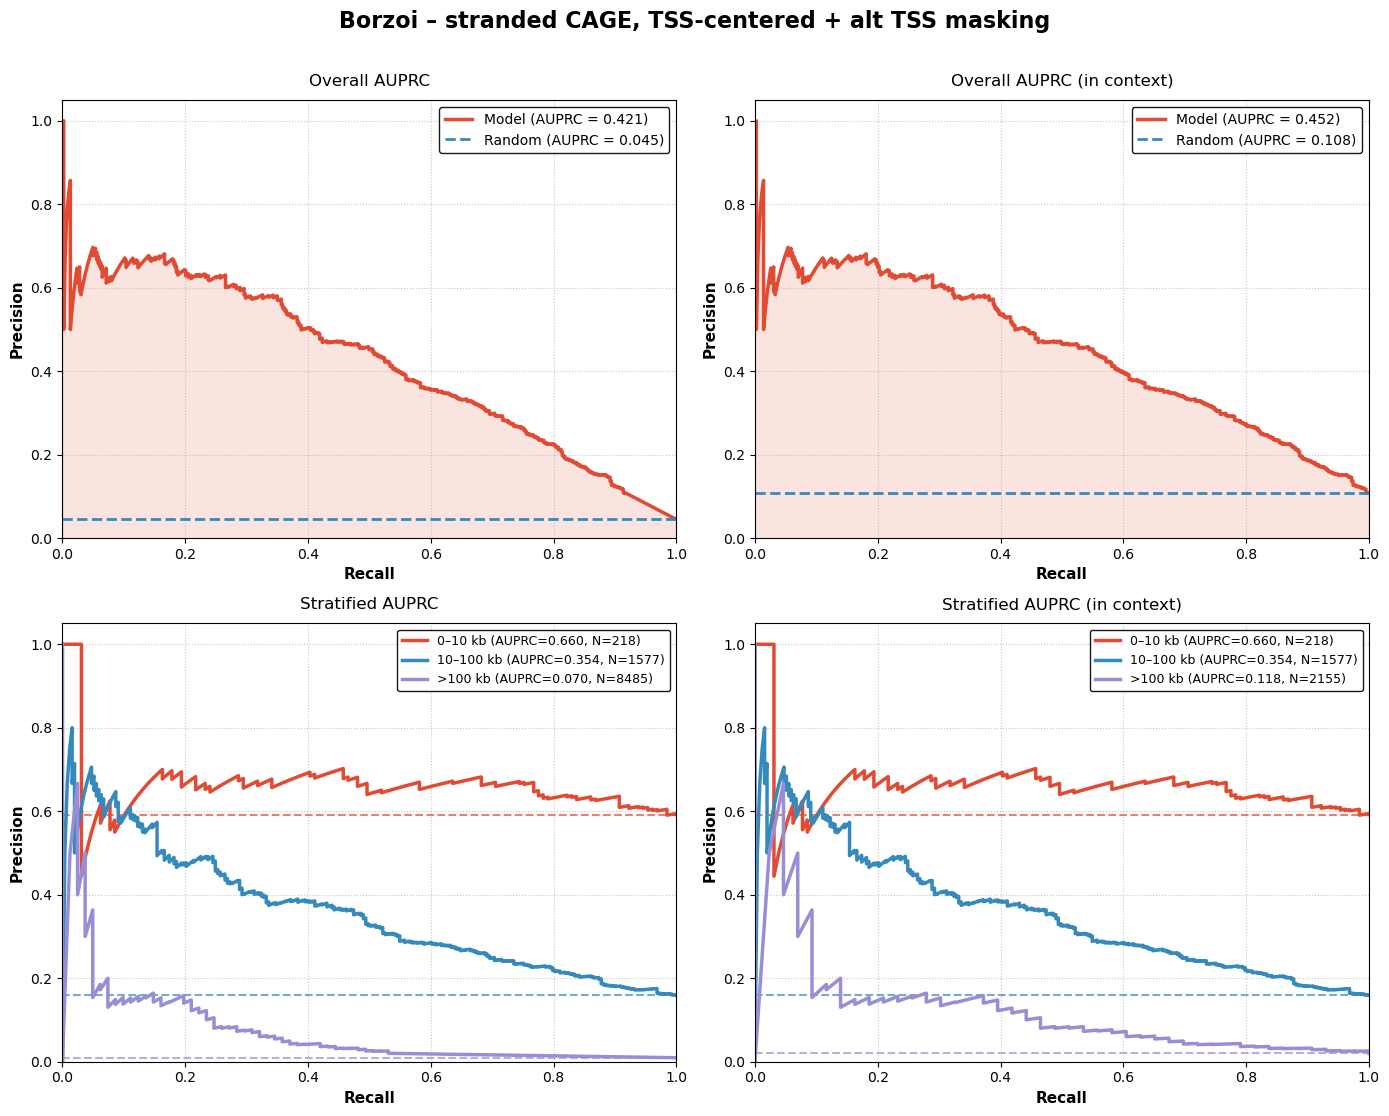

In [ ]:
mask_len_maintss = 16
mask_len_alttss = 0*4
pseudo_count = 1e-2
score_vector = make_score_vector(mask_len_maintss, mask_len_alttss, pseudo_count)
plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title='Borzoi – stranded CAGE, TSS-centered + alt TSS masking')

100%|██████████| 10280/10280 [00:00<00:00, 16018.01it/s]


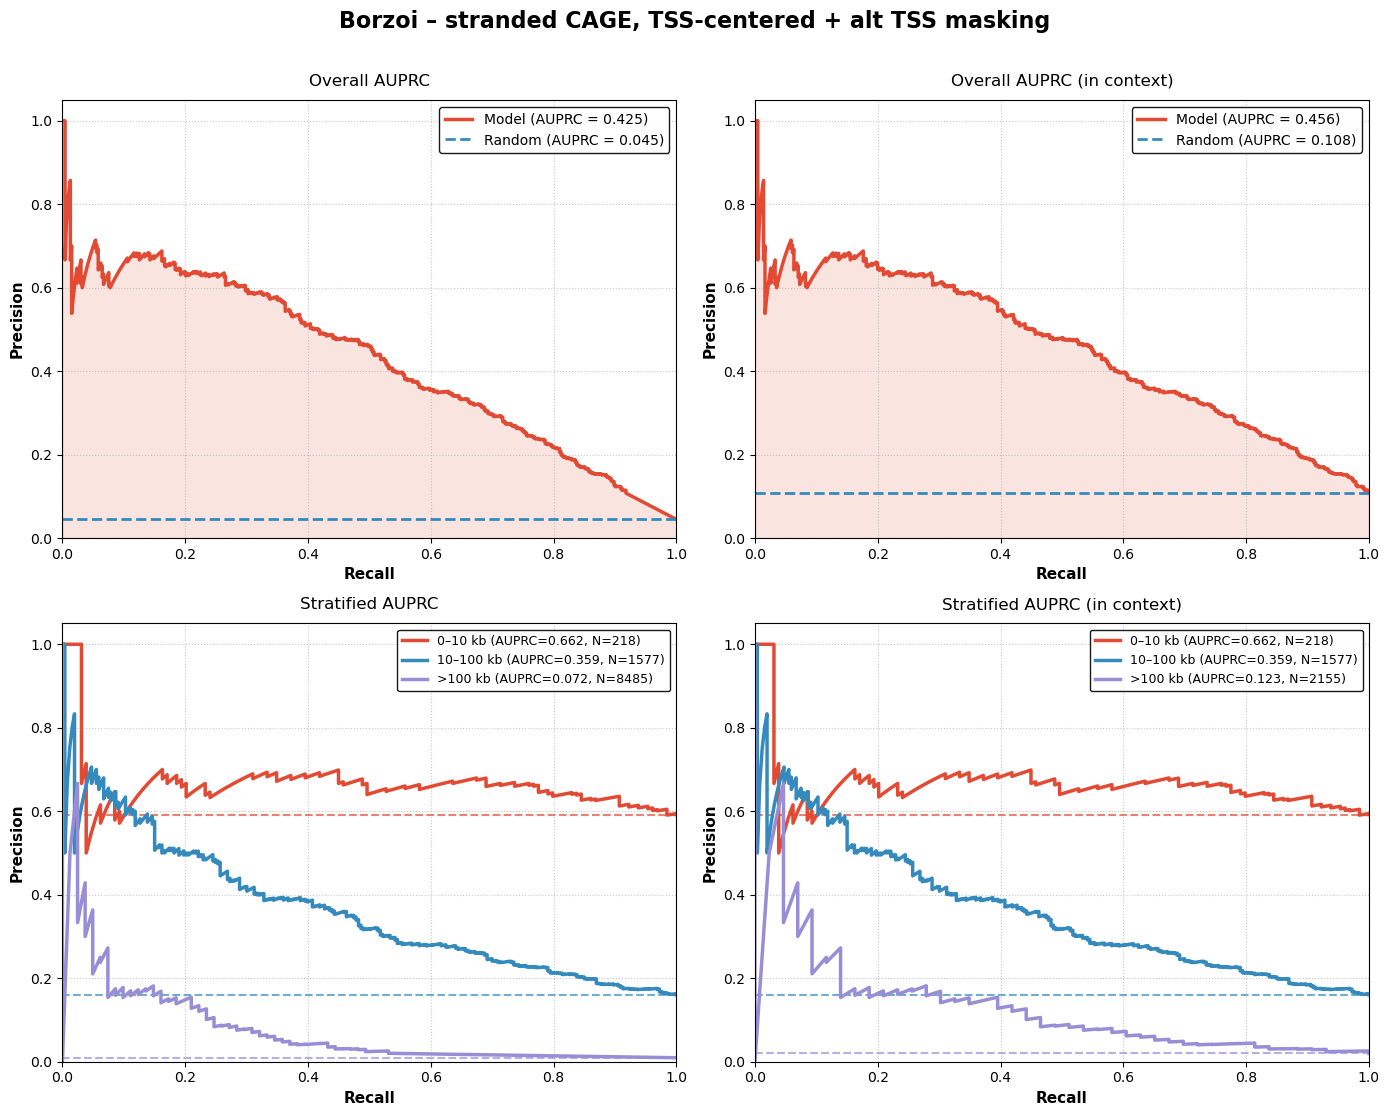

In [ ]:
mask_len_maintss = 18 #+/- 500 bp pretty much!
mask_len_alttss = 0*4
pseudo_count = 1e-2
score_vector = make_score_vector(mask_len_maintss, mask_len_alttss, pseudo_count)
plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title='Borzoi – stranded CAGE, TSS-centered + alt TSS masking')

In [ ]:
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_both_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_both_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

In [52]:
#need to test the RNA models now...
#first let's test CAGE from the RNA model

#now make this a function

def make_score_vector(mask_len_maintss, mask_len_alttss, pseudo_count):
    #seems fine, the key thing is we have to also consider strand!

    score_vector = np.zeros(len(gs_df))


    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        # Optional but highly recommended: Skip if the enhancer was outside the input crop
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']
        
        # 1. Main TSS is ALWAYS dead center now
        gene_location = 6144 // 2 
        
        startmask = max(0, gene_location - mask_len_maintss)
        endmask = min(6144, gene_location + mask_len_maintss + 1)
        
        mask = np.zeros(6144)
        mask[startmask:endmask] = 1
        
        # 2. Alt TSS locations are just their distance from the main TSS center
        alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
        
        if mask_len_alttss > 0:
            for alt in alt_tss:
                alt_location = int(6144 // 2 + alt // 32)
                
                # Alt TSSs can still fall outside the 6144-bin (~114kb) output window
                if alt_location < 0 or alt_location >= 6144:
                    continue
                
                alt_startmask = max(0, alt_location - mask_len_alttss)
                alt_endmask = min(6144, alt_location + mask_len_alttss + 1)
                mask[alt_startmask:alt_endmask] = 1
                
        # 3. Apply the mask to the vector
        tempout = outputs[i] # 4x6144
        if strand == '+':
            og_idx = 0
            alt_idx = 4
        else:
            og_idx = 1
            alt_idx = 5
        original_sum = (tempout[og_idx] * mask).sum() 
        altered_sum = (tempout[alt_idx] * mask).sum()
        
        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))
    return score_vector



In [ ]:
#now let's do some plots
mask_len_maintss = 16
mask_len_alttss = 0*4
pseudo_count = 1e-2
score_vector = make_score_vector(mask_len_maintss, mask_len_alttss, pseudo_count)
plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title='Borzoi – stranded CAGE, TSS-centered + alt TSS masking (RNA+CAGE model)')

# let's now correlate the actual values and see direction too

In [65]:
#back to unstranded
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_unstranded_enformer_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_unstranded_enformer_tss_centered_in_context.npy')

In [76]:
def make_score_vector(outputs, mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='CAGE', model_type='enformer'):
    #seems fine, the key thing is we have to also consider strand!

    score_vector = np.zeros(len(gs_df))
    if model_type == 'enformer':
        size = 896
        bin_size = 128
    elif model_type == 'borzoi':
        size = 6144
        bin_size = 32

    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        # Optional but highly recommended: Skip if the enhancer was outside the input crop
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']
        
        # 1. Main TSS is ALWAYS dead center now
        gene_location = size // 2 
        
        startmask = max(0, gene_location - mask_len_maintss)
        endmask = min(size, gene_location + mask_len_maintss + 1)
        
        mask = np.zeros(size)
        mask[startmask:endmask] = 1
        
        # 2. Alt TSS locations are just their distance from the main TSS center
        alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
        
        if mask_len_alttss > 0:
            for alt in alt_tss:
                alt_location = int(size // 2 + alt // bin_size)
                
                # Alt TSSs can still fall outside the size-bin (~114kb) output window
                if alt_location < 0 or alt_location >= size:
                    continue
                
                alt_startmask = max(0, alt_location - mask_len_alttss)
                alt_endmask = min(size, alt_location + mask_len_alttss + 1)
                mask[alt_startmask:alt_endmask] = 1
                
        # 3. Apply the mask to the vector
        tempout = outputs[i] # 4x6144
        if model_type == 'enformer':
             og_idx = 0
             alt_idx = 1
        elif model_type == 'borzoi' and assay_type == 'both':
            if strand == '+':
                og_idx = 0
                alt_idx = 4
            else:
                og_idx = 1
                alt_idx = 5
        else:
            if strand == '+':
                og_idx = 0
                alt_idx = 2
            else:
                og_idx = 1
                alt_idx = 3
        original_sum = (tempout[og_idx] * mask).sum() 
        altered_sum = (tempout[alt_idx] * mask).sum()
        
        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

    return score_vector

mask_len_maintss = 5
mask_len_alttss = 0
score_vector = make_score_vector(mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='CAGE', model_type='enformer')

TypeError: make_score_vector() missing 1 required positional argument: 'pseudo_count'

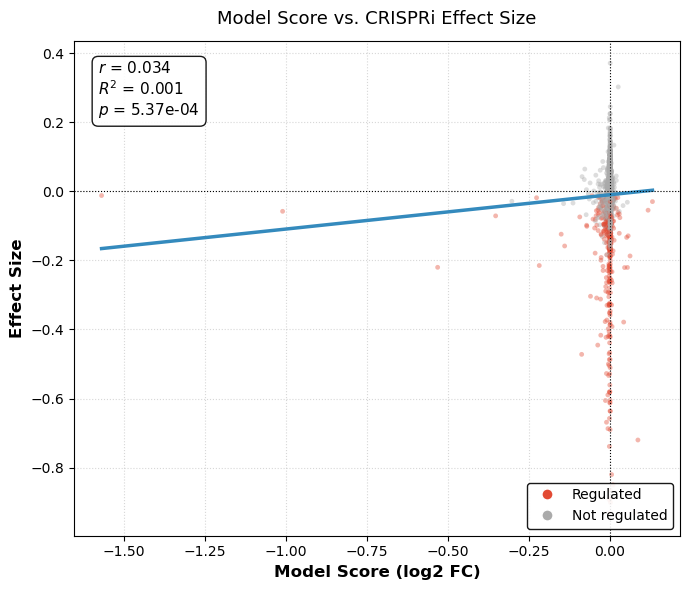

In [71]:
#now let's do a regression and plot it compared to 'EffectSize' column
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Prepare data
df_plot = gs_df.copy()
df_plot['Model_Score'] = score_vector
# df_plot = df_plot[df_plot['Regulated'] == True] # Only consider regulated pairs for the regression

# Fit regression
X = df_plot['Model_Score'].values.reshape(-1, 1)
y = df_plot['EffectSize'].values

#get only ones in cocntext

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Pearson r for annotation
r, pval = stats.pearsonr(df_plot['Model_Score'].values, y)
pval_str = f'{pval:.2e}' if pval > 1e-300 else '< 1e-300'

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter: color by Regulated status
colors = df_plot['Regulated'].map({True: '#E24A33', False: '#aaaaaa'})
ax.scatter(df_plot['Model_Score'], y,
           c=colors, alpha=0.4, s=12, linewidths=0, rasterized=True)

# Regression line
x_range = np.linspace(df_plot['Model_Score'].min(), df_plot['Model_Score'].max(), 200)
ax.plot(x_range, reg.predict(x_range.reshape(-1, 1)),
        color='#348ABD', lw=2.5, label=f'Linear fit')

# Reference lines
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.axvline(0, color='black', lw=0.8, linestyle=':')

# Annotation box
textstr = f'$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\n$p$ = {pval_str}'
ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.9))

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24A33', markersize=8, label='Regulated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaaaaa', markersize=8, label='Not regulated'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_xlabel('Model Score (log2 FC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size', fontsize=12, fontweight='bold')
ax.set_title('Model Score vs. CRISPRi Effect Size', fontsize=13, pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()



In [78]:
#now let's do the borzoi model
outputs_borzoi = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered.npy')
mask_len_maintss = 18
mask_len_alttss = 0
score_vector_borzoi = make_score_vector(outputs_borzoi,mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='CAGE', model_type='borzoi')

100%|██████████| 10280/10280 [00:00<00:00, 19150.12it/s]


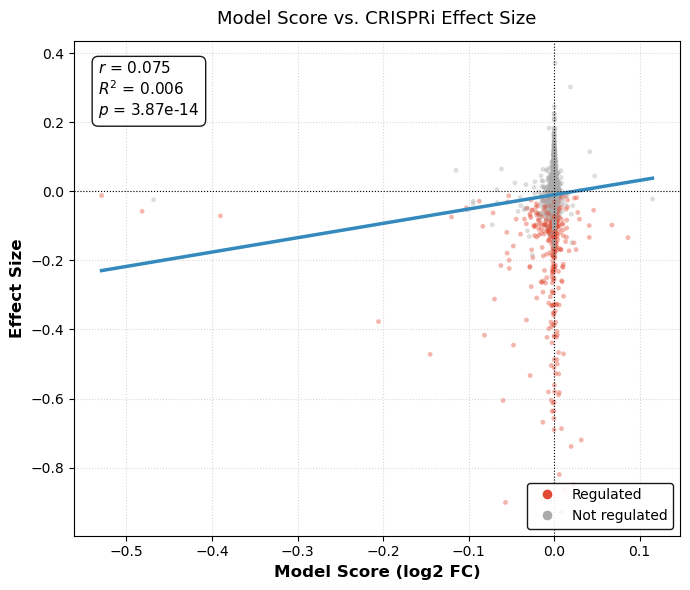

In [84]:
#now let's do a regression and plot it compared to 'EffectSize' column
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Prepare data
df_plot = gs_df.copy()
df_plot['Model_Score'] = score_vector_borzoi
# df_plot = df_plot[df_plot['Regulated'] == True] # Only consider regulated pairs for the regression
# df_plot = df_plot[in_context] # Only consider in-context pairs for the regression

# Fit regression
X = df_plot['Model_Score'].values.reshape(-1, 1)
y = df_plot['EffectSize'].values

#get only ones in cocntext

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Pearson r for annotation
r, pval = stats.pearsonr(df_plot['Model_Score'].values, y)
pval_str = f'{pval:.2e}' if pval > 1e-300 else '< 1e-300'

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter: color by Regulated status
colors = df_plot['Regulated'].map({True: '#E24A33', False: '#aaaaaa'})
ax.scatter(df_plot['Model_Score'], y,
           c=colors, alpha=0.4, s=12, linewidths=0, rasterized=True)

# Regression line
x_range = np.linspace(df_plot['Model_Score'].min(), df_plot['Model_Score'].max(), 200)
ax.plot(x_range, reg.predict(x_range.reshape(-1, 1)),
        color='#348ABD', lw=2.5, label=f'Linear fit')

# Reference lines
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.axvline(0, color='black', lw=0.8, linestyle=':')

# Annotation box
textstr = f'$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\n$p$ = {pval_str}'
ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.9))

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24A33', markersize=8, label='Regulated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaaaaa', markersize=8, label='Not regulated'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_xlabel('Model Score (log2 FC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size', fontsize=12, fontweight='bold')
ax.set_title('Model Score vs. CRISPRi Effect Size', fontsize=13, pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()



In [ ]:
#hmmm this is not great...

# now do it for the CAGE borzoi model

In [ ]:
#so here's what we would load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

# gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
# gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)
    
name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
#ensure all names are in the tss_dict
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
        
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
gs_df


,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [14]:
import numpy as np
from tqdm import tqdm

def make_score_vector(outputs, in_context, mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='CAGE', model_type='enformer'):
    #seems fine, the key thing is we have to also consider strand!

    score_vector = np.zeros(len(gs_df))
    if model_type == 'enformer':
        size = 896
        bin_size = 128
    elif model_type == 'borzoi':
        size = 6144
        bin_size = 32

    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        # Optional but highly recommended: Skip if the enhancer was outside the input crop
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']
        
        # 1. Main TSS is ALWAYS dead center now
        gene_location = size // 2 
        
        startmask = max(0, gene_location - mask_len_maintss)
        endmask = min(size, gene_location + mask_len_maintss + 1)
        
        mask = np.zeros(size)
        mask[startmask:endmask] = 1
        
        # 2. Alt TSS locations are just their distance from the main TSS center
        alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
        
        if mask_len_alttss > 0:
            for alt in alt_tss:
                alt_location = int(size // 2 + alt // bin_size)
                
                # Alt TSSs can still fall outside the size-bin (~114kb) output window
                if alt_location < 0 or alt_location >= size:
                    continue
                
                alt_startmask = max(0, alt_location - mask_len_alttss)
                alt_endmask = min(size, alt_location + mask_len_alttss + 1)
                mask[alt_startmask:alt_endmask] = 1
                
        # 3. Apply the mask to the vector
        tempout = outputs[i] # 4x6144
        if model_type == 'enformer':
             og_idx = 0
             alt_idx = 1
        elif model_type == 'borzoi' and assay_type == 'both':
            if strand == '+':
                og_idx = 0
                alt_idx = 4
            else:
                og_idx = 1
                alt_idx = 5
        else:
            if strand == '+':
                og_idx = 0
                alt_idx = 2
            else:
                og_idx = 1
                alt_idx = 3
        original_sum = (tempout[og_idx] * mask).sum() 
        altered_sum = (tempout[alt_idx] * mask).sum()
        
        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

    return score_vector

mask_len_maintss = 20
mask_len_alttss = 0
pseudo_count = 1e-2

outputs_borzoi_both = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_both_tss_centered.npy')
in_context_both = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_both_tss_centered_in_context.npy')
score_vector_borzoi_both = make_score_vector(outputs_borzoi_both, in_context_both, mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='both', model_type='borzoi')

distance_vector = np.zeros(len(gs_df))
for i, row in gs_df.iterrows():
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    distance_vector[i] = abs(temp_tss - ((start+end)//2))
gs_df['distance_to_tss'] = distance_vector

100%|██████████| 10280/10280 [00:00<00:00, 20747.53it/s]


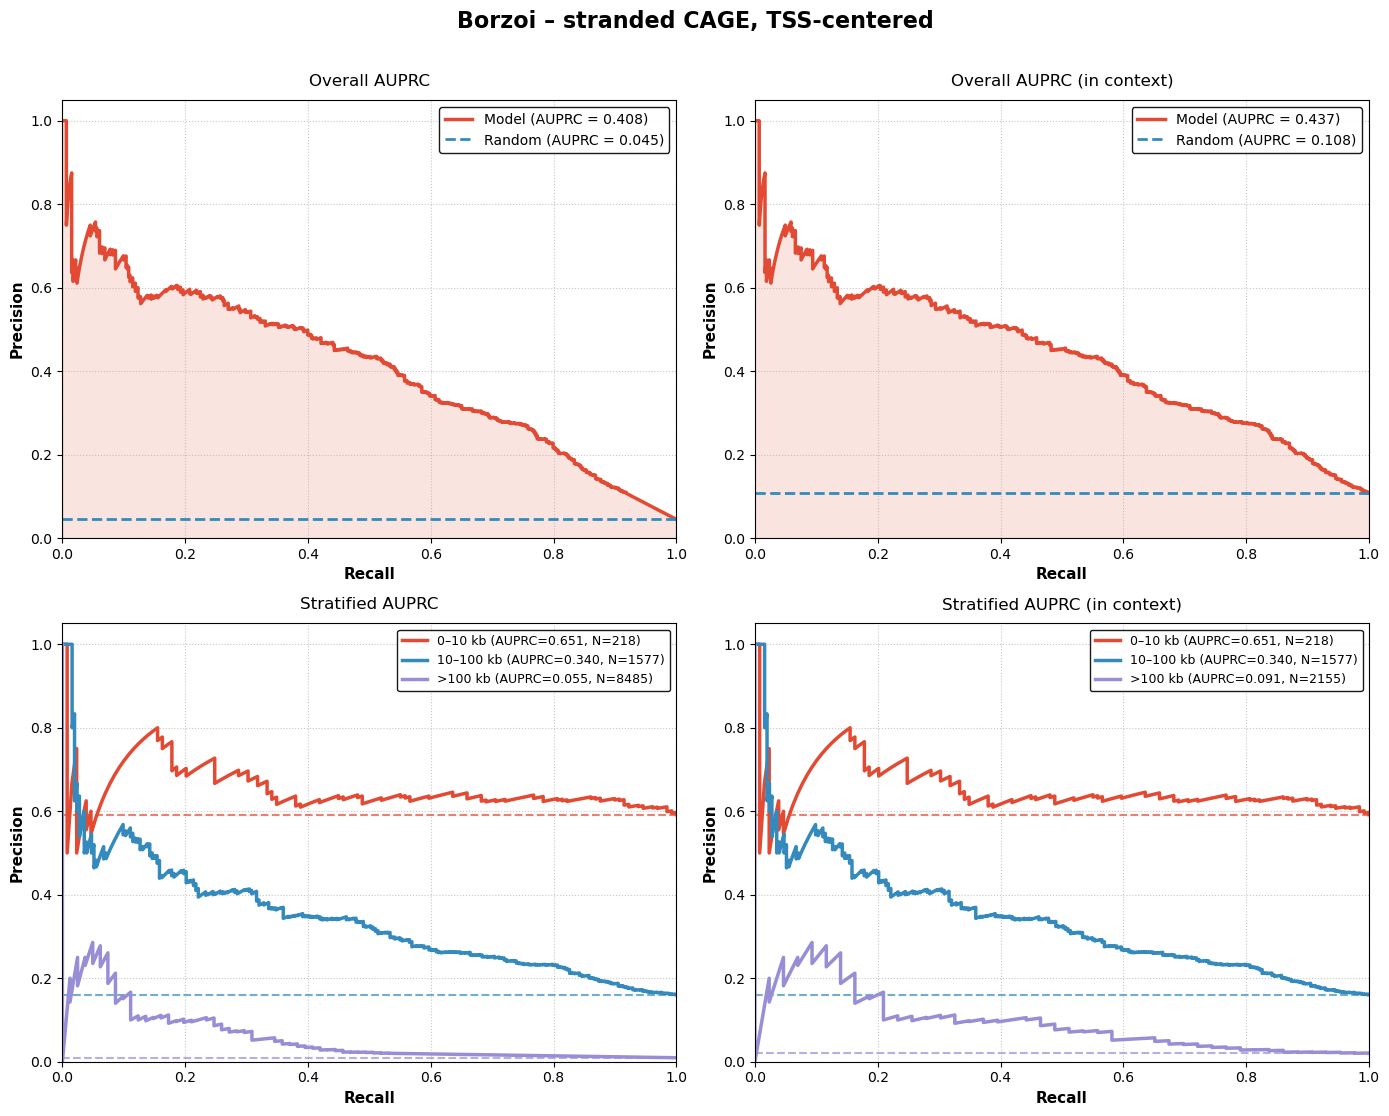

In [15]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title=None):
    """
    2x2 subplot summary of AUPRC performance.
    
    Parameters
    ----------
    score_vector  : np.ndarray (N,)  – pre-computed scores (e.g. log2 fold-change)
    in_context    : np.ndarray (N,)  – boolean mask of enhancers within the input crop
    gs_df         : pd.DataFrame     – must contain 'Regulated' column
    distance_vector : np.ndarray (N,) – enhancer-to-TSS distances (absolute values)
    title         : str, optional    – overall figure suptitle
    """
    y_score_all = np.abs(score_vector)
    y_true_all  = gs_df['Regulated'].astype(int).values
    dist_all    = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx  = y_true_all[in_context]
    dist_ctx    = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",    lambda d: d <= 10_000),
        ("10–100 kb",  lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",    lambda d: d > 100_000),
    ]
    bin_colors = ['#E24A33', '#348ABD', '#988ED5']

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    # ── helper: single overall PR curve ──────────────────────────────────────
    def _plot_overall(ax, y_true, y_score, subtitle):
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        aupr     = auc(rec, prec)
        baseline = y_true.mean()

        ax.plot(rec, prec, color='#E24A33', lw=2.5,
                label=f'Model (AUPRC = {aupr:.3f})')
        ax.fill_between(rec, prec, alpha=0.15, color='#E24A33')
        ax.axhline(baseline, color='#348ABD', lw=2, linestyle='--',
                   label=f'Random (AUPRC = {baseline:.3f})')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

    # ── helper: distance-stratified PR curves ────────────────────────────────
    def _plot_stratified(ax, y_true, y_score, distances, subtitle):
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances)
            if mask.sum() == 0:
                continue
            yt, ys = y_true[mask], y_score[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr     = auc(rec, prec)
            baseline = yt.mean()
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f'{label} (AUPRC={aupr:.3f}, N={mask.sum()})')
            ax.axhline(baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='black')

    # ── fill the 4 panels ────────────────────────────────────────────────────
    _plot_overall   (axes[0, 0], y_true_all, y_score_all, 'Overall AUPRC')
    _plot_overall   (axes[0, 1], y_true_ctx, y_score_ctx, 'Overall AUPRC (in context)')
    _plot_stratified(axes[1, 0], y_true_all, y_score_all, dist_all, 'Stratified AUPRC')
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx, 'Stratified AUPRC (in context)')

    plt.tight_layout()
    plt.show()


# ── example usage ─────────────────────────────────────────────────────────────
# plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector,
#                title='Enformer – unstranded CAGE, TSS-centered')



plot_auprc_2x2(score_vector_borzoi_both, in_context_both, gs_df, distance_vector, title='Borzoi – stranded CAGE, TSS-centered')